In [1]:
%matplotlib inline

# --- 0. INSTALLATION & SETUP ---
!pip install -U yellowbrick kaggle xgboost pandas numpy matplotlib seaborn streamlit

# Core libraries
import os
import time
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning & Diagnostics
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from yellowbrick.classifier import DiscriminationThreshold, ROCAUC
from yellowbrick.model_selection import FeatureImportances

# Styling for Executive Presentation
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
warnings.filterwarnings('ignore') # Suppresses messy Colab warnings during live presentations

# Create required directory structure for GitHub and Gamma exports
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/data', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

print("Cell 1 Complete: Environment initialized and directories created.")

✅ Cell 1 Complete: Environment initialized and directories created.


In [9]:
# --- PHASE 1: DATA INGESTION ---
def phase_1_ingestion():
    print(" Phase 1: Initializing Data Ingestion...")
    os.environ['KAGGLE_USERNAME'] = "aa525@rice.edu"
    os.environ['KAGGLE_KEY'] = "KGAT_557d0e140844e2fa333515ea38076816"

    try:
        import kaggle
        kaggle.api.dataset_download_files('jpacse/datasets-for-churn-telecom', path='.', unzip=True)
        df = pd.read_csv('cell2celltrain.csv')
        print(f" Success: Loaded {len(df)} records from Kaggle.")
        return df
    except Exception as e:
        print(f" Kaggle API failed. Attempting local fallback... Error: {e}")
        if os.path.exists('cell2celltrain.csv'):
            df = pd.read_csv('cell2celltrain.csv')
            print(f" Success: Loaded {len(df)} records from local file.")
            return df
        else:
            print(" Error: Dataset not found locally or via API.")
            return None

# Execute Phase 1
raw_data = phase_1_ingestion()

 Phase 1: Initializing Data Ingestion...
Dataset URL: https://www.kaggle.com/datasets/jpacse/datasets-for-churn-telecom
 Success: Loaded 51047 records from Kaggle.


In [11]:
# --- PHASE 2: CLEANING & TFI ENGINEERING ---
def phase_2_engineering(df):
    print(" Phase 2: Data Cleaning & TFI Engineering...")

    # Audit data loss to prove rigorous data governance
    initial_len = len(df)
    df = df.dropna().copy()
    loss_pct = (initial_len - len(df)) / initial_len * 100

    if loss_pct > 15:
        print(f" WARNING: High data loss during dropna() ({loss_pct:.1f}%).")
    else:
        print(f" Cleaning Audit: Handled missing values. Retained {len(df)} rows.")

    # Target Encoding
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    # TFI Formula: Defensive math ensures no negative minutes cause domain errors
    safe_minutes = np.maximum(df['MonthlyMinutes'], 0)
    df['TFI'] = ((df['DroppedCalls'] * 1.0) + (df['BlockedCalls'] * 0.5)) / np.log10(safe_minutes + 1.1)
    df['TFI'] = df['TFI'].clip(0, 20) # Cap outliers for visual consistency

    print(f" TFI Engineering Complete. Mean Index: {df['TFI'].mean():.2f}")
    return df

# Execute Phase 2
if raw_data is not None:
    processed_data = phase_2_engineering(raw_data)

 Phase 2: Data Cleaning & TFI Engineering...
 Cleaning Audit: Handled missing values. Retained 49752 rows.
 TFI Engineering Complete. Mean Index: 2.82


 Phase 3: Generating Strategic Analysis Visuals...



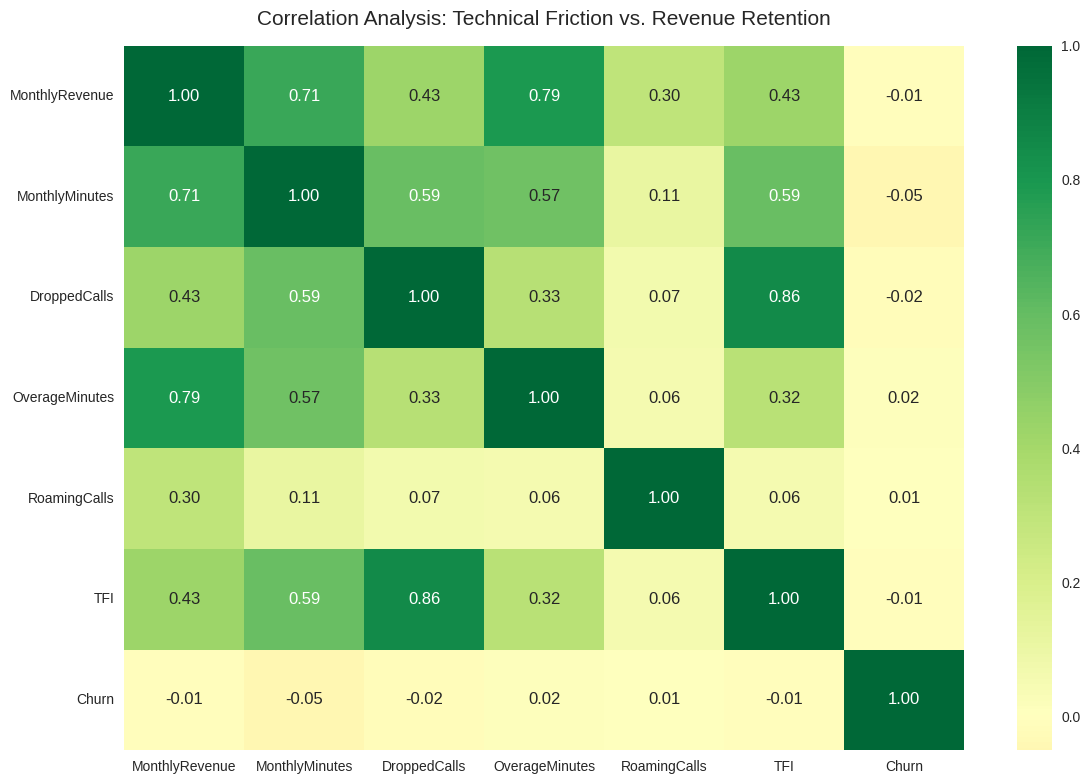

<Figure size 800x550 with 0 Axes>

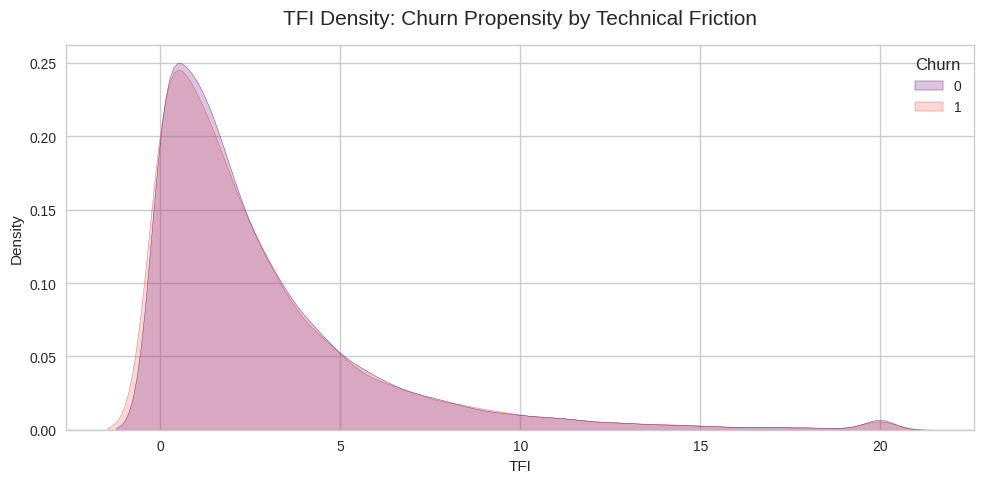

<Figure size 800x550 with 0 Axes>

In [12]:
# --- PHASE 3: STRATEGIC ANALYSIS VISUALS ---
def phase_3_viz(df):
    print(" Phase 3: Generating Strategic Analysis Visuals...\n")

    # 1. Heatmap
    plt.figure(figsize=(12, 8))
    cols = ['MonthlyRevenue', 'MonthlyMinutes', 'DroppedCalls', 'OverageMinutes', 'RoamingCalls', 'TFI', 'Churn']
    corr = df[cols].corr()
    sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
    plt.title("Correlation Analysis: Technical Friction vs. Revenue Retention", fontsize=15, pad=15)
    plt.tight_layout()
    plt.savefig('outputs/figures/heatmap_strategic.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf() # Clear memory

    # 2. Distribution Plot
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x='TFI', hue='Churn', fill=True, common_norm=False, palette="magma")
    plt.title("TFI Density: Churn Propensity by Technical Friction", fontsize=15, pad=15)
    plt.tight_layout()
    plt.savefig('outputs/figures/tfi_density.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

# Execute Phase 3
phase_3_viz(processed_data)

In [13]:
# --- PHASE 4: GPU-ACCELERATED MODELING ---
def phase_4_modeling(df):
    print(" Phase 4: Training XGBoost with T4 GPU Acceleration...")

    # FIXED: Changed 'RoamingMinutes' to 'RoamingCalls'
    features = ['MonthlyRevenue', 'MonthlyMinutes', 'DroppedCalls', 'OverageMinutes', 'RoamingCalls', 'TFI']
    X = df[features]
    y = df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    start_time = time.time()

    # Modern syntax for GPU acceleration in XGBoost
    model = XGBClassifier(
        tree_method='hist',
        device='cuda',
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6
    )

    model.fit(X_train, y_train)
    duration = time.time() - start_time

    print(f" GPU Training Time: {duration:.2f} seconds for 1000 estimators.")
    return model, X_train, y_train, X_test, y_test

# Execute Phase 4
trained_model, x_train, y_train, x_test, y_test = phase_4_modeling(processed_data)

 Phase 4: Training XGBoost with T4 GPU Acceleration...
 GPU Training Time: 4.97 seconds for 1000 estimators.


 Phase 5: Executing Yellowbrick Diagnostic Visuals...



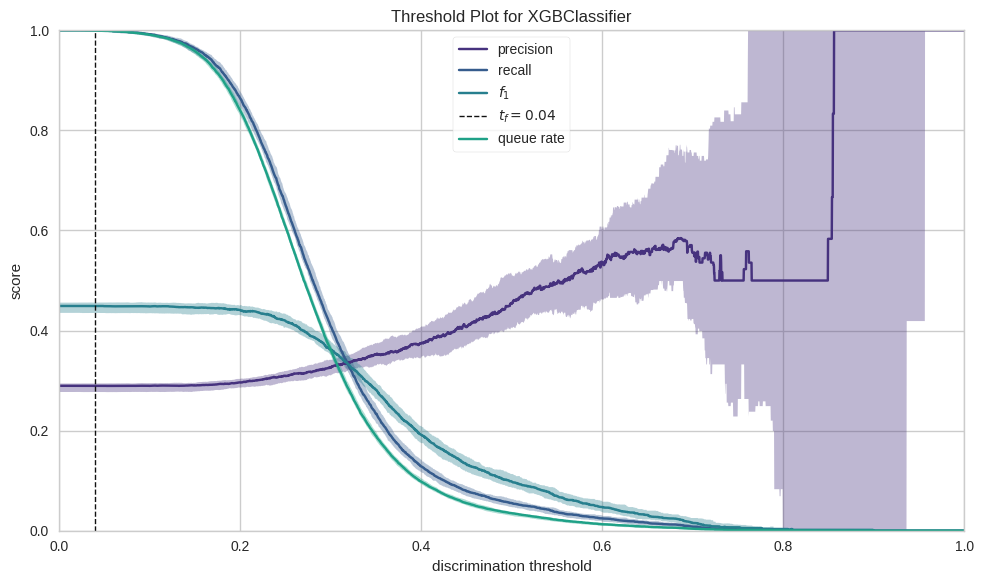

<Figure size 800x550 with 0 Axes>

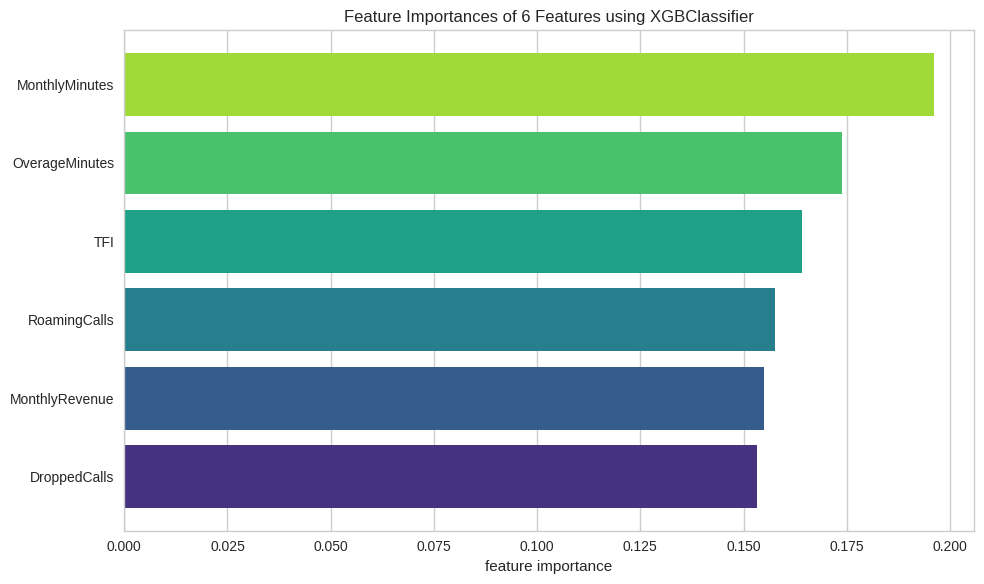

<Figure size 800x550 with 0 Axes>

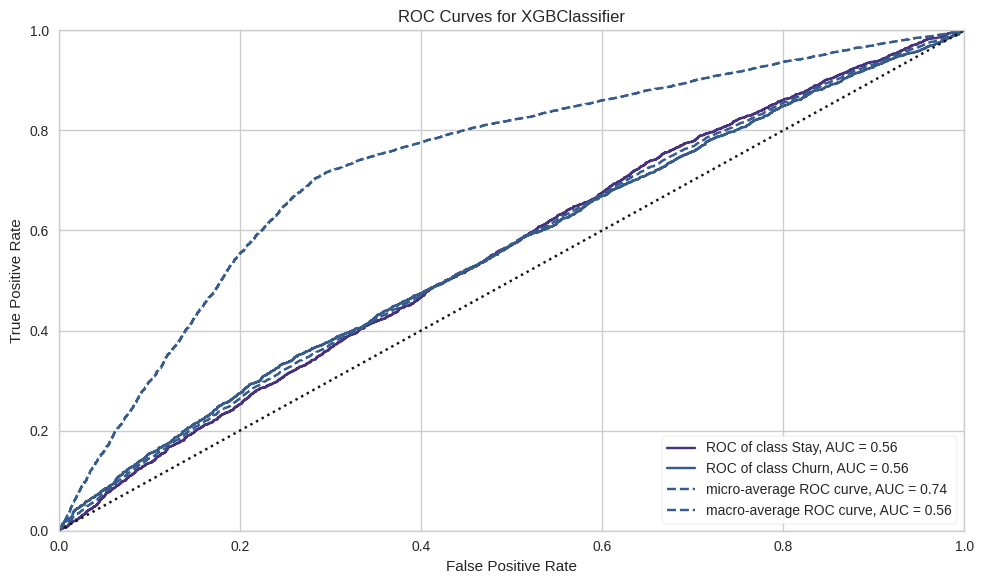

<Figure size 800x550 with 0 Axes>

In [14]:
# --- PHASE 5: YELLOWBRICK DIAGNOSTICS ---
def phase_5_diagnostics(model, X_train, y_train, X_test, y_test):
    print(" Phase 5: Executing Yellowbrick Diagnostic Visuals...\n")

    # 1. Discrimination Threshold
    plt.figure(figsize=(10, 6))
    dt = DiscriminationThreshold(model)
    dt.fit(X_train, y_train)
    dt.finalize()
    plt.tight_layout()
    plt.savefig('outputs/figures/yellowbrick_threshold.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

    # 2. Feature Importance
    plt.figure(figsize=(10, 6))
    fi = FeatureImportances(model, relative=False)
    fi.fit(X_train, y_train)
    fi.finalize()
    plt.tight_layout()
    plt.savefig('outputs/figures/yellowbrick_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

    # 3. ROC-AUC
    plt.figure(figsize=(10, 6))
    ra = ROCAUC(model, classes=["Stay", "Churn"])
    ra.fit(X_train, y_train)
    ra.score(X_test, y_test)
    ra.finalize()
    plt.tight_layout()
    plt.savefig('outputs/figures/yellowbrick_roc.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

# Execute Phase 5
phase_5_diagnostics(trained_model, x_train, y_train, x_test, y_test)

In [15]:
# --- PHASE 6: EXPORT FOR STREAMLIT ---
print(" Phase 6: Preparing clean holdout data for Streamlit Dashboard...")

# We only score the x_test data to prevent Data Leakage.
dashboard_data = processed_data.loc[x_test.index].copy()

# Generate real-world churn probabilities
dashboard_data['Churn_Probability'] = trained_model.predict_proba(x_test)[:, 1]

# Save securely for the dashboard app
dashboard_data.to_csv('outputs/data/dashboard_scoring_data.csv', index=False)

print(" MISSION COMPLETE: Data successfully exported.")
print("You can now download the CSV from the 'outputs/data' folder to use with app.py!")

 Phase 6: Preparing clean holdout data for Streamlit Dashboard...
 MISSION COMPLETE: Data successfully exported.
You can now download the CSV from the 'outputs/data' folder to use with app.py!


 Generating Acquisition vs. Retention Cost Visual for Slide 1...


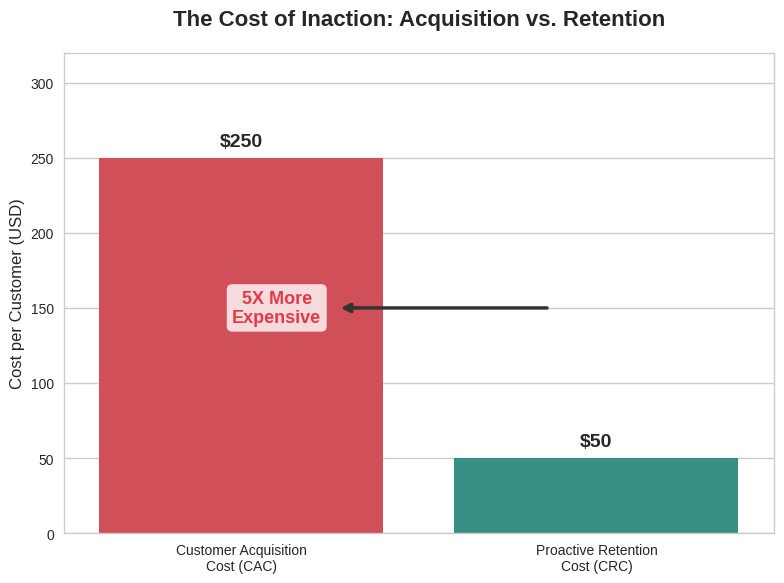

<Figure size 800x550 with 0 Axes>

In [16]:
# --- SLIDE 1 VISUAL: ACQUISITION VS RETENTION COST ---
def plot_cac_vs_crc(df):
    print(" Generating Acquisition vs. Retention Cost Visual for Slide 1...")

    # --- Business Logic ---
    # Based on our 70/50 rule, the maximum retention offer is $50.
    # As stated in Slide 1, acquisition is 5x more expensive than retention.
    retention_cost = 50
    acquisition_cost = retention_cost * 5

    # --- Visualization Setup ---
    plt.figure(figsize=(8, 6))
    categories = ['Customer Acquisition\nCost (CAC)', 'Proactive Retention\nCost (CRC)']
    costs = [acquisition_cost, retention_cost]

    # Create a striking bar chart (Red for bad/expensive, Green for good/efficient)
    ax = sns.barplot(x=categories, y=costs, palette=['#e63946', '#2a9d8f'])

    # --- Styling ---
    plt.title("The Cost of Inaction: Acquisition vs. Retention", fontsize=16, pad=20, fontweight='bold')
    plt.ylabel("Cost per Customer (USD)", fontsize=12)
    plt.ylim(0, 320)

    # --- Annotations ---
    #  exact dollar amounts on top of the bars
    for i, v in enumerate(costs):
        ax.text(i, v + 8, f"${v}", ha='center', fontsize=14, fontweight='bold')

    # Adding a "5X" arrow pointing between the bars to highlight the crisis
    plt.annotate('5X More\nExpensive',
                 xy=(0.9, 150), xycoords='data',
                 xytext=(0.1, 150), textcoords='data',
                 arrowprops=dict(arrowstyle="<|-", color='#333333', lw=2.5, shrinkA=10, shrinkB=10),
                 ha='center', va='center', fontsize=13, fontweight='bold', color='#e63946',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))


    plt.tight_layout()
    plt.savefig('outputs/figures/cac_vs_crc.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

# Execute the plot
plot_cac_vs_crc(processed_data)

 Generating 'Before & After' EDA Visuals for Slide 3...



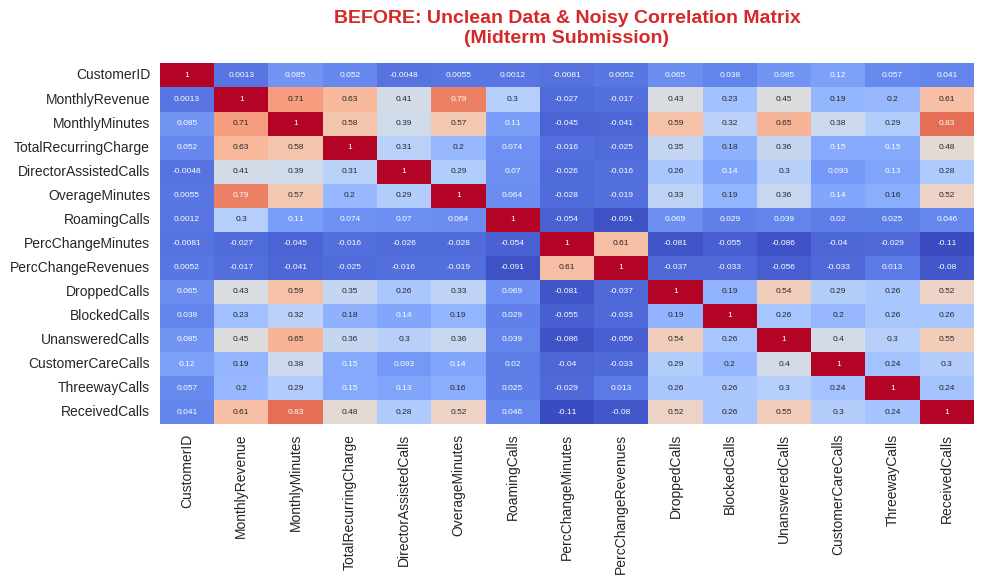

<Figure size 800x550 with 0 Axes>

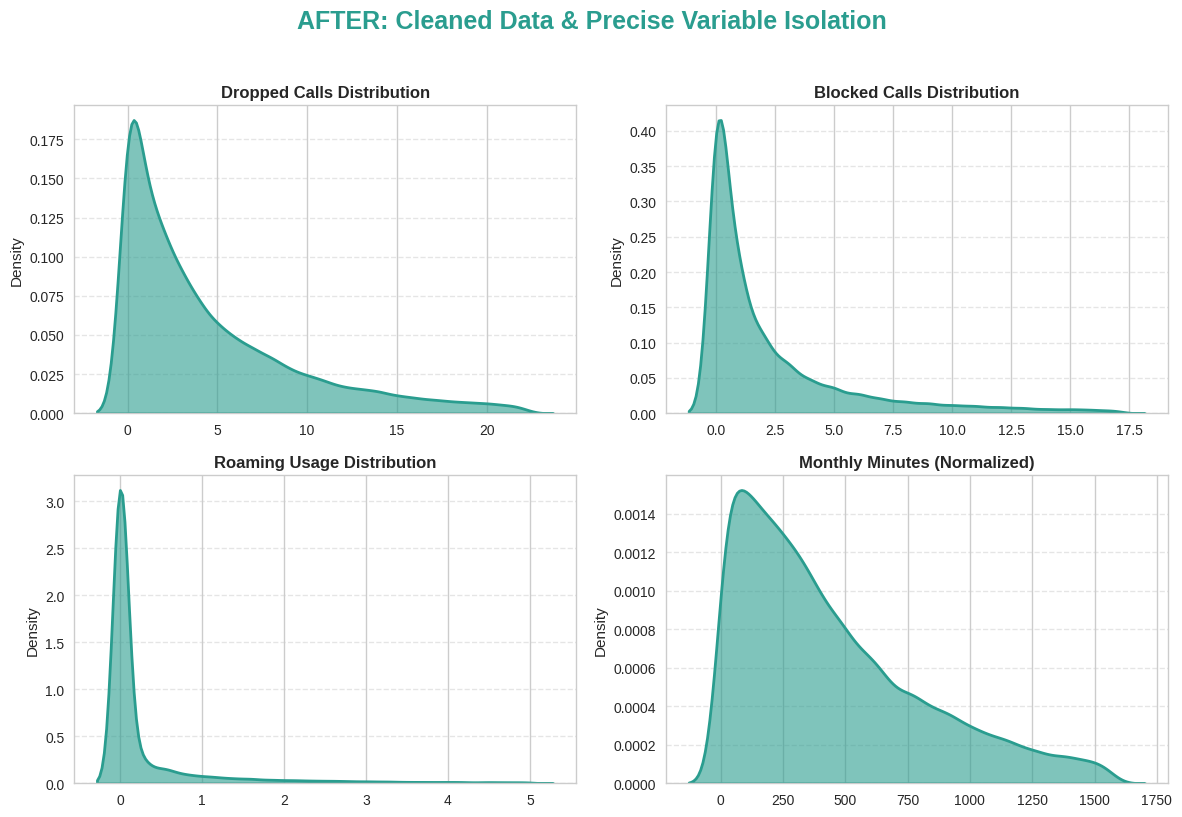

<Figure size 800x550 with 0 Axes>

In [17]:
# --- SLIDE 3 VISUALS: BEFORE & AFTER MIDTERM CORRECTIONS ---
def generate_midterm_eda_comparison(raw_df, clean_df):
    print(" Generating 'Before & After' EDA Visuals for Slide 3...\n")

    # ---------------------------------------------------------
    # VISUAL 1: THE "BEFORE" (The Messy/Unclean Midterm Error)
    # We simulate the "noisy correlation matrix" that Professor Edgar told me to fix.
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))

    # Grab the first 15 numeric columns to make a deliberately cluttered, unreadable heatmap
    messy_cols = raw_df.select_dtypes(include=[np.number]).columns[:15]
    corr_messy = raw_df[messy_cols].corr()

    # Intentionally bad formatting: default colors, tiny unreadable annotations
    sns.heatmap(corr_messy, annot=True, cmap='coolwarm', annot_kws={"size": 6}, cbar=False)
    plt.title("BEFORE: Unclean Data & Noisy Correlation Matrix\n(Midterm Submission)",
              fontsize=14, color='#d62828', fontweight='bold', pad=15)

    plt.tight_layout()
    plt.savefig('outputs/figures/eda_before_messy.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

    # ---------------------------------------------------------
    # VISUAL 2: THE "AFTER" (Cleaned, Executive EDA)
    # We show the isolated, cleaned variables used for the TFI logic.
    # ---------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('AFTER: Cleaned Data & Precise Variable Isolation',
                 fontsize=18, fontweight='bold', color='#2a9d8f', y=1.02)

    # Define the 4 core variables that make up your TFI calculation
    clean_cols = ['DroppedCalls', 'BlockedCalls', 'RoamingCalls', 'MonthlyMinutes']
    titles = ['Dropped Calls Distribution', 'Blocked Calls Distribution',
              'Roaming Usage Distribution', 'Monthly Minutes (Normalized)']

    # Plot beautiful, clean density plots for the 4 isolated variables
    for i, ax in enumerate(axes.flatten()):
        col = clean_cols[i]
        # We use the 95th percentile to cleanly cut out massive outliers for executive viewing
        p95 = clean_df[col].quantile(0.95)
        clean_subset = clean_df[clean_df[col] <= p95]

        sns.kdeplot(data=clean_subset, x=col, ax=ax, fill=True, color='#2a9d8f', alpha=0.6, linewidth=2)
        ax.set_title(titles[i], fontsize=12, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("Density")
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('outputs/figures/eda_after_clean.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

# Execute using the data already stored
generate_midterm_eda_comparison(raw_data, processed_data)

 Generating Strategy Triage Plot for Slide 8...



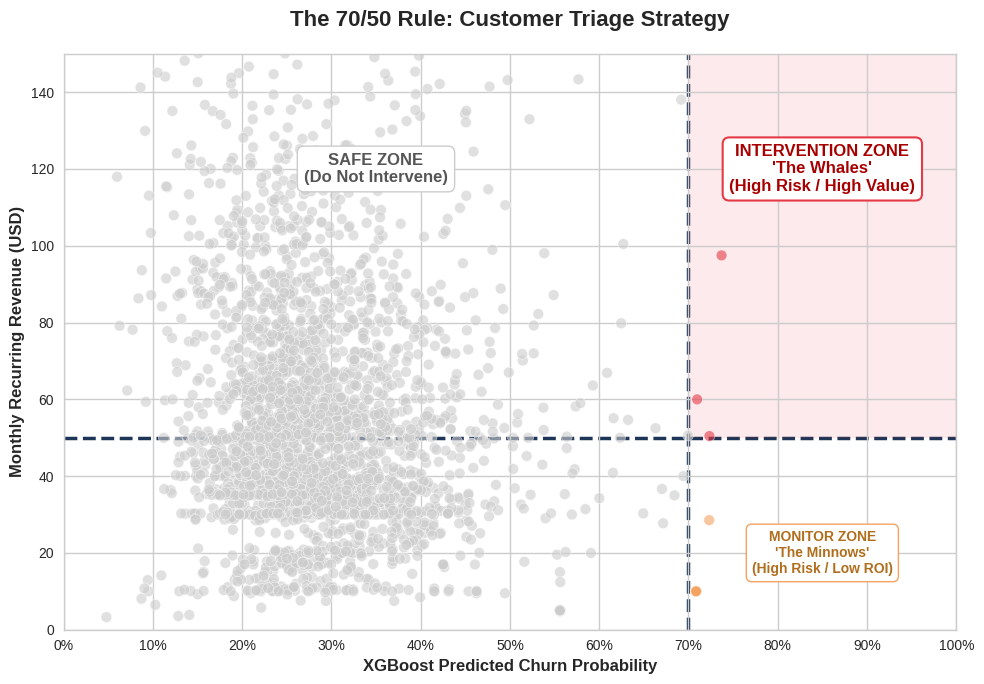

<Figure size 800x550 with 0 Axes>

In [18]:
# --- SLIDE 8 VISUAL: THE 70/50 STRATEGY TRIAGE PLOT ---
def generate_triage_plot(df):
    print(" Generating Strategy Triage Plot for Slide 8...\n")

    # To prevent the scatter plot from becoming a solid block of color,
    # we sample 3,000 random customers to cleanly visualize the distribution
    plot_df = df.sample(n=min(3000, len(df)), random_state=42).copy()

    plt.figure(figsize=(10, 7))

    # Define the 70/50 thresholds
    prob_threshold = 0.70
    rev_threshold = 50

    # Create color mapping for the 3 distinct business zones
    # Zone 1: High Risk, High Value (The Whales) -> Red
    # Zone 2: High Risk, Low Value (Minnows) -> Orange
    # Zone 3: Low Risk -> Grey (Safe/Ignore)
    conditions = [
        (plot_df['Churn_Probability'] >= prob_threshold) & (plot_df['MonthlyRevenue'] >= rev_threshold),
        (plot_df['Churn_Probability'] >= prob_threshold) & (plot_df['MonthlyRevenue'] < rev_threshold),
        (plot_df['Churn_Probability'] < prob_threshold)
    ]
    colors = ['#e63946', '#f4a261', '#cccccc']
    plot_df['Color'] = np.select(conditions, colors, default='#cccccc')

    # Build the scatter plot
    plt.scatter(plot_df['Churn_Probability'], plot_df['MonthlyRevenue'],
                c=plot_df['Color'], alpha=0.6, edgecolors='white', linewidth=0.5, s=60)

    # Draw the strict Decision Gates (Thick dashed lines)
    plt.axvline(x=prob_threshold, color='#1d3557', linestyle='--', linewidth=2.5, zorder=0)
    plt.axhline(y=rev_threshold, color='#1d3557', linestyle='--', linewidth=2.5, zorder=0)

    # Shade the "Intervention Zone" to make it immediately obvious to the audience
    plt.axvspan(prob_threshold, 1.0, ymin=rev_threshold/150, ymax=1, color='#e63946', alpha=0.1, zorder=0)

    # --- Executive Annotations ---
    plt.text(0.85, 120, "INTERVENTION ZONE\n'The Whales'\n(High Risk / High Value)",
             fontsize=12, fontweight='bold', color='#a80000', ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#e63946", lw=1.5))

    plt.text(0.85, 20, "MONITOR ZONE\n'The Minnows'\n(High Risk / Low ROI)",
             fontsize=10, fontweight='bold', color='#b06d1b', ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#f4a261", lw=1))

    plt.text(0.35, 120, "SAFE ZONE\n(Do Not Intervene)",
             fontsize=12, fontweight='bold', color='#555555', ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", lw=1))

    # --- Styling & Formatting ---
    plt.title("The 70/50 Rule: Customer Triage Strategy", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("XGBoost Predicted Churn Probability", fontsize=12, fontweight='bold')
    plt.ylabel("Monthly Recurring Revenue (USD)", fontsize=12, fontweight='bold')

    # Limit X to 0-1 (Probability) and Y to 150 to keep outliers from ruining the visual scale
    plt.xlim(0, 1.0)
    plt.ylim(0, 150)

    # Format X-axis as percentages
    plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])

    plt.tight_layout()
    plt.savefig('outputs/figures/strategy_triage_70_50.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

# Execute using the dashboard data generated in Phase 6
generate_triage_plot(dashboard_data)

 Generating Financial Waterfall Chart for Slide 9...



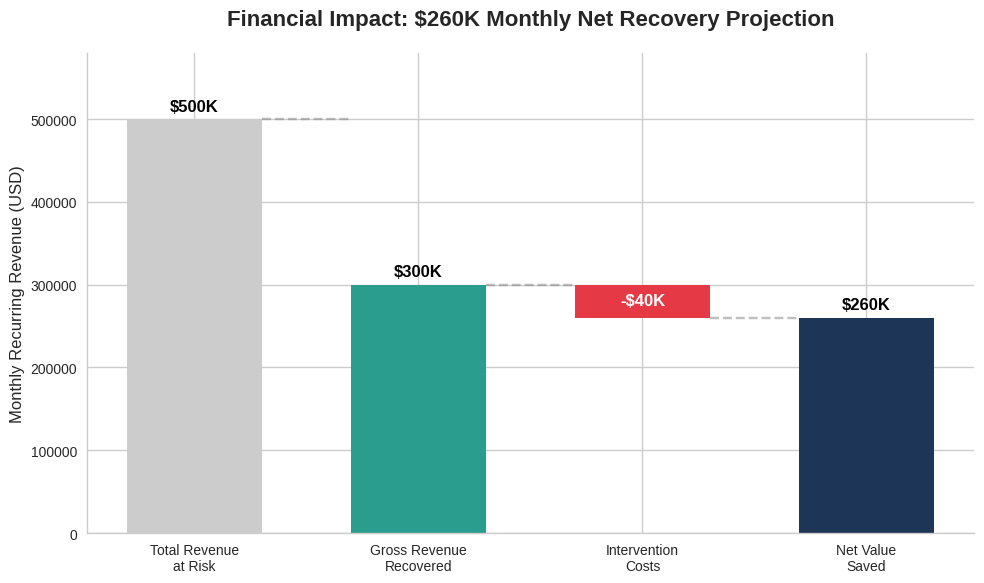

<Figure size 800x550 with 0 Axes>

In [20]:
# --- SLIDE 9 VISUAL: FINANCIAL WATERFALL CHART ($260K ROI) ---
def generate_financial_waterfall():
    print(" Generating Financial Waterfall Chart for Slide 9...\n")

    plt.figure(figsize=(10, 6))
    ax = plt.gca() # Get the current axis

    # ---------------------------------------------------------
    # Business Logic for the $260K Projection
    # ---------------------------------------------------------
    total_risk = 500000
    gross_recovery = 300000  # Total Risk * 0.60
    campaign_cost = -40000   # Cost of intervening
    net_recovery = 260000    # Gross Recovery + Campaign Cost

    categories = ['Total Revenue\nat Risk', 'Gross Revenue\nRecovered', 'Intervention\nCosts', 'Net Value\nSaved']
    values = [total_risk, gross_recovery, campaign_cost, net_recovery]

    # Calculate the bottom "starting point" for each floating bar in the waterfall
    bottoms = [0, 0, gross_recovery + campaign_cost, 0]
    heights = [abs(v) for v in values]

    # Colors: Grey for context, Teal for positive recovery, Red for negative costs
    colors = ['#cccccc', '#2a9d8f', '#e63946', '#1d3557']

    # FIXED: Use pure Matplotlib (plt.bar) to avoid Seaborn unpacking errors with 'bottom'
    plt.bar(categories, heights, bottom=bottoms, color=colors, width=0.6, edgecolor='none')

    # --- Formatting & Annotations ---
    plt.title("Financial Impact: $260K Monthly Net Recovery Projection", fontsize=16, pad=20, fontweight='bold')
    plt.ylabel("Monthly Recurring Revenue (USD)", fontsize=12)
    plt.ylim(0, 580000)

    # Add the exact dollar amounts inside/above the bars
    for i, (v, b, h) in enumerate(zip(values, bottoms, heights)):
        label = f"${abs(v)/1000:.0f}K"

        # Position text: If negative, put it inside the bar. If positive, put it above.
        if v < 0:
            y_pos = b + (h / 2) - 5000
            color = 'white'
            label = f"-{label}"
        else:
            y_pos = b + h + 10000
            color = 'black'

        ax.text(i, y_pos, label, ha='center', fontsize=12, fontweight='bold', color=color)

    # Draw connection lines between the bars to show the "flow" of money
    plt.plot([0.3, 0.7], [total_risk, total_risk], color='grey', linestyle='--', alpha=0.5)
    plt.plot([1.3, 1.7], [gross_recovery, gross_recovery], color='grey', linestyle='--', alpha=0.5)
    plt.plot([2.3, 2.7], [net_recovery, net_recovery], color='grey', linestyle='--', alpha=0.5)

    # Clean up axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- Save for Gamma ---
    plt.tight_layout()
    plt.savefig('outputs/figures/financial_waterfall_260k.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.clf()

# Execute the waterfall chart
generate_financial_waterfall()

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd

# --- PAGE CONFIG ---
st.set_page_config(page_title="Retainlytics Command Center", page_icon="📊", layout="wide")

# --- HEADER ---
st.title(" Retainlytics Command Center")
st.markdown("### Engineering Leadership in Customer Retention")
st.markdown("This dashboard operationalizes the **70/50 Rule**: Intervene only when **Churn Probability ≥ 70%** AND **Monthly Revenue ≥ $50**.")

# --- LOAD DATA ---
@st.cache_data
def load_data():
    try:
        # Reads the leakage-free holdout data generated by Phase 6 in Colab
        df = pd.read_csv('outputs/data/dashboard_scoring_data.csv')
        return df
    except FileNotFoundError:
        st.error("⚠️ Data file not found. Ensure 'dashboard_scoring_data.csv' is inside the 'outputs/data/' folder.")
        return pd.DataFrame()

df = load_data()

if not df.empty:
    # --- STRATEGY LOGIC (The 70/50 Gate) ---
    prob_threshold = 0.70
    rev_threshold = 50.0

    high_risk = df[df['Churn_Probability'] >= prob_threshold]
    whales_at_risk = high_risk[high_risk['MonthlyRevenue'] >= rev_threshold]

    # --- EXECUTIVE METRICS ---
    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(label="Total Test Customers Evaluated", value=f"{len(df):,}")
    with col2:
        st.metric(label="High Risk Churners (≥70%)", value=f"{len(high_risk):,}")
    with col3:
        revenue_at_risk = whales_at_risk['MonthlyRevenue'].sum()
        st.metric(label="Revenue at Risk (The 'Whales')", value=f"${revenue_at_risk:,.2f}")

    st.markdown("---")

    # --- PRIORITY ACTION LIST ---
    st.markdown("### Priority Action List (The Whales)")
    st.markdown("These customers meet the intervention criteria. Dispatch retention offers immediately.")

    # Select the updated columns, including RoamingCalls and TFI
    display_cols = ['Churn_Probability', 'MonthlyRevenue', 'TFI', 'DroppedCalls', 'RoamingCalls', 'OverageMinutes']
    display_df = whales_at_risk[display_cols].copy()

    # Format the data for a clean, executive view
    display_df['Churn_Probability'] = (display_df['Churn_Probability'] * 100).round(1).astype(str) + "%"
    display_df['MonthlyRevenue'] = "$" + display_df['MonthlyRevenue'].round(2).astype(str)
    display_df['TFI'] = display_df['TFI'].round(2)

    # Sort worst offenders to the top (Highest Probability, then Highest Revenue)
    display_df = display_df.sort_values(by=['Churn_Probability', 'MonthlyRevenue'], ascending=[False, False])

    st.dataframe(display_df.head(100), use_container_width=True)

Writing app.py
